Failed encoding utf-8: 'utf-8' codec can't decode byte 0xa3 in position 16: invalid start byte
Failed encoding utf-8-sig: 'utf-8' codec can't decode byte 0xa3 in position 7092: invalid start byte
Loaded '/content/Stock News Dataset.csv' with encoding=cp1252, shape=(4101, 27)
After combining, shape: (4101, 28)
Label distribution:
 Label
1    2166
0    1935
Name: count, dtype: int64


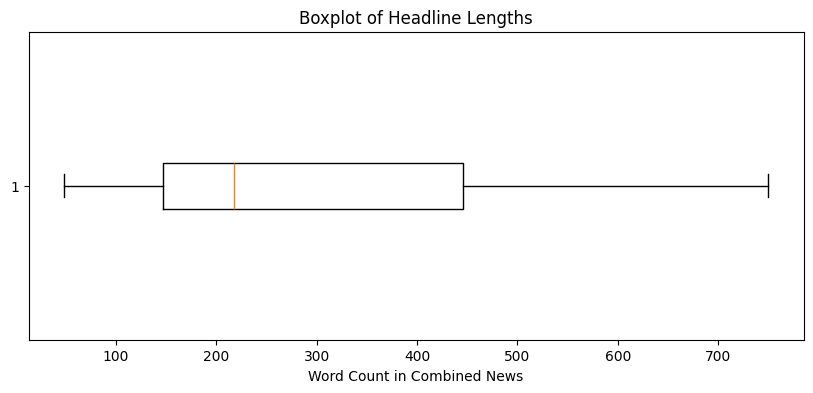

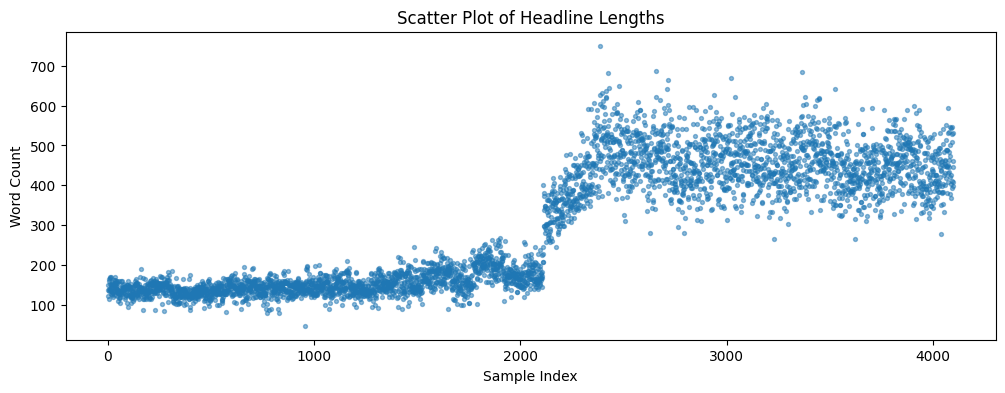

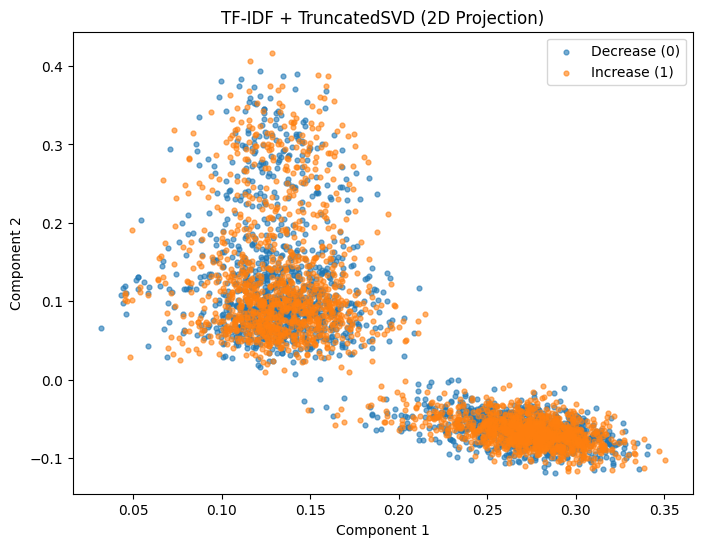

Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Generating FinBERT embeddings...



100%|██████████| 257/257 [15:08<00:00,  3.54s/it]


Embeddings shape: (4101, 768)

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.4590    0.4625    0.4607       387
           1     0.5174    0.5138    0.5156       434

    accuracy                         0.4896       821
   macro avg     0.4882    0.4882    0.4882       821
weighted avg     0.4899    0.4896    0.4897       821


=== Confusion Matrix (raw numbers) ===
[[179 208]
 [211 223]]


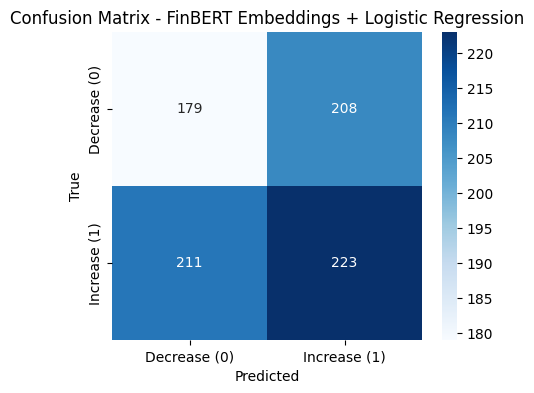

Saved classifier+scaler to 'finbert_clf.joblib'


100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


Sample: drug decriminalization in portugal decreases number of addicts pounds of silver ...
Prediction: Increase (p_up=0.859)

Sample: megaupload founder defeats us govt attempts to put him back in prison end destru...
Prediction: Decrease (p_up=0.121)

Sample: not just william mtk hungaria celtic rangers fc copenhagen ranieri move puts mak...
Prediction: Increase (p_up=0.634)


In [ ]:
# ======= Colab-ready: install dependencies =======
!pip -q install transformers torch scikit-learn pandas matplotlib seaborn joblib

# ======= Imports =======
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import joblib

import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ======= 0) Robust CSV load =======
CSV_PATH = "/content/Stock News Dataset.csv"   # adjust path if needed
missing_values = ["?", "N/A", "na", "null", " ", ""]

def load_csv(path):
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin1"):
        try:
            df = pd.read_csv(path, encoding=enc, na_values=missing_values)
            print(f"Loaded '{path}' with encoding={enc}, shape={df.shape}")
            return df
        except Exception as e:
            print(f"Failed encoding {enc}: {e}")
    raise RuntimeError("Could not read CSV with tried encodings.")

df = load_csv(CSV_PATH)

# ======= 1) Combine headlines =======
headline_cols = [f"Top{i}" for i in range(1, 26)]
present_headline_cols = [c for c in headline_cols if c in df.columns]

if len(present_headline_cols) == 0:
    raise ValueError("Dataset is missing Top1..Top25 headline columns. Found: " + ", ".join(df.columns))

# keep only rows with labels
df['Label'] = df['Label'].astype('float')
df = df.dropna(subset=['Label']).copy()
df['Label'] = df['Label'].astype(int)

# fill missing headlines and combine
df[present_headline_cols] = df[present_headline_cols].fillna("")
df['Combined_News'] = df[present_headline_cols].astype(str).agg(' '.join, axis=1)

print("After combining, shape:", df.shape)
print("Label distribution:\n", df['Label'].value_counts())

# ======= 2) Clean text =======
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['Processed_News'] = df['Combined_News'].apply(clean_text)

# ======= 3) Exploratory Data Analysis (EDA) =======
# Headline lengths
df['headline_length'] = df['Processed_News'].str.split().apply(len)

# Boxplot
plt.figure(figsize=(10,4))
plt.boxplot(df['headline_length'], vert=False)
plt.xlabel("Word Count in Combined News")
plt.title("Boxplot of Headline Lengths")
plt.show()

# Scatter plot
plt.figure(figsize=(12,4))
plt.scatter(range(len(df)), df['headline_length'], alpha=0.5, s=8)
plt.xlabel("Sample Index")
plt.ylabel("Word Count")
plt.title("Scatter Plot of Headline Lengths")
plt.show()

# TF-IDF + SVD 2D visualization
nonempty_mask = df['Processed_News'].str.strip() != ""
sample_texts = df.loc[nonempty_mask, 'Processed_News'].values
if len(sample_texts) >= 2:
    vect = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english")
    X_tfidf = vect.fit_transform(sample_texts)
    svd = TruncatedSVD(n_components=2, random_state=42)
    X_2d = svd.fit_transform(X_tfidf)
    labels_viz = df.loc[nonempty_mask, 'Label'].values

    plt.figure(figsize=(8,6))
    mask0 = labels_viz == 0
    mask1 = labels_viz == 1
    plt.scatter(X_2d[mask0,0], X_2d[mask0,1], label="Decrease (0)", alpha=0.6, s=12)
    plt.scatter(X_2d[mask1,0], X_2d[mask1,1], label="Increase (1)", alpha=0.6, s=12)
    plt.legend()
    plt.title("TF-IDF + TruncatedSVD (2D Projection)")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()
else:
    print("Not enough non-empty texts for TF-IDF visualization.")

# ======= 4) FinBERT embedding =======
MODEL_NAME = "yiyanghkust/finbert-tone"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

def embed_texts(texts, batch_size=16, max_length=64):
    all_embs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_length, return_tensors="pt")
            enc = {k: v.to(DEVICE) for k,v in enc.items()}
            outputs = model(**enc)
            cls_emb = outputs.last_hidden_state[:,0,:].cpu().numpy()
            all_embs.append(cls_emb)
    return np.vstack(all_embs)

texts = df['Processed_News'].tolist()
print("Generating FinBERT embeddings...")
X = embed_texts(texts)
y = df['Label'].values
print("Embeddings shape:", X.shape)

# ======= 5) Train/test split =======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ======= 6) Train classifier =======
clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
clf.fit(X_train_scaled, y_train)

# ======= 7) Evaluate =======
y_pred = clf.predict(X_test_scaled)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix (raw numbers) ===")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Decrease (0)", "Increase (1)"],
            yticklabels=["Decrease (0)", "Increase (1)"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - FinBERT Embeddings + Logistic Regression")
plt.show()

# ======= 8) Save artifacts =======
joblib.dump({"classifier": clf, "scaler": scaler}, "finbert_clf.joblib")
print("Saved classifier+scaler to 'finbert_clf.joblib'")

# ======= 9) Example inference =======
def predict_headlines(headlines):
    clean = [clean_text(h) for h in headlines]
    embs = embed_texts(clean)
    embs_scaled = scaler.transform(embs)
    preds = clf.predict(embs_scaled)
    probs = clf.predict_proba(embs_scaled)[:,1]
    return preds, probs

demo_samples = df['Processed_News'].sample(3, random_state=0).tolist()
preds, probs = predict_headlines(demo_samples)
for txt, p, pr in zip(demo_samples, preds, probs):
    print(f"\nSample: {txt[:80]}...")
    print(f"Prediction: {'Increase' if p==1 else 'Decrease'} (p_up={pr:.3f})")


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np

# Load the dataset with the correct encoding
try:
    df = pd.read_csv('/content/Stock News Dataset.csv', encoding='latin1')
except FileNotFoundError:
    print("Error: The file 'Stock News Dataset.csv' was not found. Please ensure the file is in the correct path.")
    exit()

# Combine all headline columns into a single text column
df_headlines = df.iloc[:, 2:27]
df_headlines.replace(to_replace='\\n', value=' ', regex=True, inplace=True)
headlines = []
for row in range(len(df_headlines.index)):
    headlines.append(' '.join(str(x) for x in df_headlines.iloc[row, :]))

# Add the combined headlines to the dataframe
df['headlines'] = headlines

# Load the FinBERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Create a function to get FinBERT embeddings
def get_finbert_embeddings(texts, model, tokenizer):
    model.eval()
    embeddings = []
    for text in texts:
        inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        # Get the embeddings from the last hidden state of the [CLS] token
        last_hidden_state = outputs.hidden_states[-1]
        cls_embedding = last_hidden_state[:, 0, :].squeeze().numpy()
        embeddings.append(cls_embedding)
    return np.array(embeddings)

# Preprocessing
X = df['headlines']
y = df['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Get FinBERT embeddings for training and testing data
print("Generating FinBERT embeddings for the training data...")
X_train_embeddings = get_finbert_embeddings(X_train.tolist(), model, tokenizer)
print("Generating FinBERT embeddings for the test data...")
X_test_embeddings = get_finbert_embeddings(X_test.tolist(), model, tokenizer)

# Train a Logistic Regression model on the embeddings
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train_embeddings, y_train)

# Make predictions on the test set for overall accuracy
y_pred = classifier.predict(X_test_embeddings)
overall_accuracy = accuracy_score(y_test, y_pred) * 100

# Make predictions on the first 10 rows of the original data
first_10_df = df.head(10).copy()
X_first_10 = first_10_df['headlines']
X_first_10_embeddings = get_finbert_embeddings(X_first_10.tolist(), model, tokenizer)
y_first_10_pred = classifier.predict(X_first_10_embeddings)

# Create the output dataframe for the first 10 rows
predictions_df = pd.DataFrame({
    'Date': first_10_df['Date'],
    'true_label': first_10_df['Label'],
    'predicted_label': y_first_10_pred
})

# Display the results
print("\n✅ Predictions on first 10 rows:")
print(predictions_df.to_string(index=False))
print(f"\n✅ Overall Accuracy: {overall_accuracy:.2f}%")
import torch
print("GPU available:", torch.cuda.is_available())

Generating FinBERT embeddings for the training data...
Generating FinBERT embeddings for the test data...

✅ Predictions on first 10 rows:
      Date  true_label  predicted_label
2000-01-03           0                0
2000-01-04           0                0
2000-01-05           0                0
2000-01-06           1                1
2000-01-07           1                1
2000-01-10           1                1
2000-01-11           1                0
2000-01-12           0                0
2000-01-13           1                1
2000-01-14           1                1

✅ Overall Accuracy: 51.40%
GPU available: False
